# Classification EEG avec SVM

Ce notebook présente l’étape de classification supervisée appliquée aux données EEG prétraitées. À partir des caractéristiques extraites dans le notebook précédent, plusieurs variantes de modèles **Support Vector Machine (SVM)** sont évaluées afin de distinguer les participants du groupe **H** (contrôles sains) du groupe **MDD** (dépression majeure).

Les analyses comprennent :
- le chargement des caractéristiques et des labels
- la séparation en ensembles d’entraînement et de validation
- l’entraînement d’un modèle SVM de base
- l’exploration de différentes stratégies d’optimisation, incluant :
  - l’ajustement d’hyperparamètres
  - la sélection de variables
  - la réduction de dimension

Les performances sont ensuite évaluées à l’aide de l’**exactitude (accuracy)** et de la **matrice de confusion**.

## 1. Importation des librairies

Cette section importe les bibliothèques nécessaires pour :
- charger et manipuler les données numériques (`numpy`, `os`)
- entraîner les modèles SVM (`SVC`)
- construire des pipelines de traitement (`Pipeline`)
- standardiser les variables (`StandardScaler`)
- réduire la dimension ou sélectionner les variables (`PCA`, `SelectPercentile`, `SelectKBest`)
- effectuer la validation croisée et la recherche d’hyperparamètres (`KFold`, `GridSearchCV`, `train_test_split`)
- évaluer les performances du modèle (`accuracy_score`, `confusion_matrix`)
- visualiser les résultats (`matplotlib`, `seaborn`)

In [ ]:
import os
import numpy as np
import seaborn as sns
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GridSearchCV, GroupShuffleSplit
from sklearn.feature_selection import SelectPercentile, f_classif, SelectKBest
from sklearn.metrics import accuracy_score, confusion_matrix

## 2. Définition des dossiers

Cette section définit les dossiers de travail utilisés dans le projet :
- `source_data_dir` pour les données sources
- `output_data_dir` pour les données générées et sauvegardées

In [2]:
source_data_dir = os.environ.get("SOURCE_DATA_DIR", "source_data")
output_data_dir = os.environ.get("OUTPUT_DATA_DIR", "output_data")

## 3. Chargement des caractéristiques prétraitées et des labels

Les fichiers utilisés dans ce notebook proviennent du notebook de prétraitement précédent et sont chargés à partir du dossier `output_data` situé dans le dépôt GitHub.

Les fichiers chargés sont les suivants :

- `X_epochs_data.npy` : données EEG segmentées en époques
- `X_features.npy` : caractéristiques extraites à partir des bandes de fréquence
- `y_epoch_labels.npy` : étiquettes de groupe associées à chaque époque

Ces matrices constituent les données d’entrée utilisées pour l’entraînement et l’évaluation des modèles de classification supervisée.

In [3]:
X_epochs   = np.load(os.path.join(output_data_dir, "X_epochs_data.npy"))
X_features = np.load(os.path.join(output_data_dir, "X_features.npy"))
y_labels   = np.load(os.path.join(output_data_dir, "y_epoch_labels.npy"))

print(X_epochs.shape)
print(X_features.shape)
print(y_labels.shape)

(4329, 19, 1024)
(4329, 95)
(4329,)


## 4. Séparation des données en ensembles d’entraînement et de validation

Les données sont divisées en deux ensembles :
- un ensemble d’entraînement servant à ajuster les modèles
- un ensemble de validation conservé pour l’évaluation

La fonction `train_test_split` est utilisée avec une stratification des labels (`stratify=y_labels`) afin de préserver la proportion des classes dans les deux sous-ensembles.

In [ ]:
subject_ids = np.load(os.path.join(output_data_dir, "subject_ids.npy"))

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_features, y_labels, groups=subject_ids))

X_train, X_test = X_features[train_idx], X_features[test_idx]
y_train, y_test = y_labels[train_idx],   y_labels[test_idx]

print(f"Train : {len(X_train)} époques ({len(np.unique(subject_ids[train_idx]))} sujets)")
print(f"Test  : {len(X_test)} époques ({len(np.unique(subject_ids[test_idx]))} sujets)")

Train size: 2597
Validation size: 1732


## 5. Modèle SVM de base avec validation croisée à 10 plis

Cette première analyse évalue un modèle SVM linéaire de base appliqué aux caractéristiques EEG extraites. Le pipeline comprend une étape de standardisation, suivie d’un classificateur SVM.

Le modèle est évalué à l’aide d’une validation croisée à **10 plis** sur l’ensemble d’entraînement. À chaque pli :
- le modèle est ajusté sur les données d’entraînement du pli
- des prédictions sont générées sur les données test du pli
- les résultats sont combinés pour calculer les mesures de performance globales

In [5]:
# Construction du pipeline de classification :
# 1) standardisation des variables
# 2) classification avec un SVM linéaire
model = Pipeline([
        ('scaler', StandardScaler()),
        # ('feature_selection',SelectPercentile(f_classif,percentile=20)),
        ('prediction', SVC(kernel='linear', C=100, gamma=1))
                 ])

# Conteneurs pour stocker les prédictions et les indices testés à chaque pli
y_pred = [] 
y_index = [] 

# Validation croisée à 10 plis
skf = KFold(n_splits=10, shuffle=True, random_state=123)

# Sous-ensembles d'entraînement et de test pour le pli courant
for tr_ind, te_ind in skf.split(X_train):
    X_tr = X_train[tr_ind]
    y_tr = y_train[tr_ind]
    X_te = X_train[te_ind]

    # Sauvegarde des indices des observations testées
    y_index += list(te_ind) 
    
    # Entraînement du modèle
    model.fit(X_tr, y_tr)

    # Prédictions sur le sous-ensemble test
    predictions = model.predict(X_te).tolist() 
    y_pred += predictions 

### 5.1 Évaluation de l’exactitude

L’exactitude (*accuracy*) correspond à la proportion totale d’époques correctement classées par le modèle. Elle est calculée ici à partir des prédictions obtenues lors de la validation croisée.

In [6]:
acc = accuracy_score(y_train[y_index], y_pred)

print('ACC:',acc)

ACC: 0.9526376588371197


### 5.2 Matrice de confusion

La matrice de confusion permet de visualiser la répartition des classifications correctes et incorrectes entre les deux groupes. Elle fournit une lecture plus détaillée des performances du modèle que l’exactitude seule.

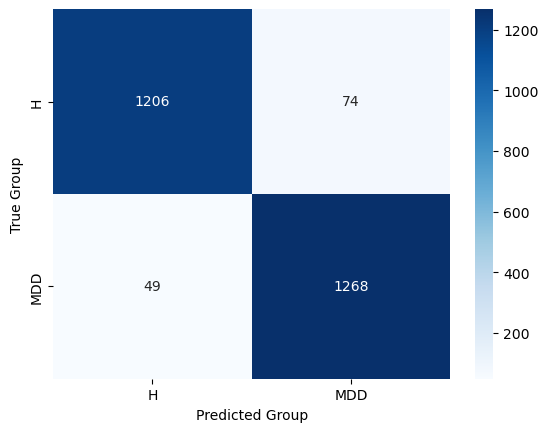

In [7]:
cm = confusion_matrix(y_train[y_index], y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H', 'MDD'],
            yticklabels=['H', 'MDD'])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.show()

## 6. Ajustement des hyperparamètres avec GridSearchCV

Cette section explore différentes combinaisons d’hyperparamètres pour le modèle SVM à l’aide d’une recherche sur grille (*GridSearchCV*). L’objectif est d’identifier la combinaison de paramètres offrant les meilleures performances en validation croisée.

Les paramètres explorés sont :
- `C` : paramètre de régularisation
- `gamma` : paramètre contrôlant l’influence des observations

In [8]:
# Définition de la grille d'hyperparamètres à explorer
param_grid = {
    'prediction__C': 10. ** np.arange(-2, 4),      
    'prediction__gamma': 10. ** np.arange(-2, 4)   
}

# Définition de la grille d'hyperparamètres à explorer
grid = GridSearchCV(model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=1)

# Recherche sur grille avec validation croisée à 5 plis
grid.fit(X_train, y_train)

# Ajustement de la grille sur les données d'entraînement
print(grid.best_params_)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


{'prediction__C': 100.0, 'prediction__gamma': 0.01}


## 7. SVM avec sélection de variables par SelectPercentile

Cette variante ajoute une étape de sélection de variables avant la classification. La méthode `SelectPercentile` conserve ici les **20 % de variables les plus informatives** selon le test ANOVA (`f_classif`).

Cette approche vise à réduire le bruit et à conserver uniquement les caractéristiques les plus pertinentes pour distinguer les groupes.

In [9]:
# Pipeline de classification avec sélection des 20 % de variables les plus informatives
model = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection',SelectPercentile(f_classif,percentile=20)),
        ('prediction', SVC(kernel='linear', C=100, gamma=1))
                 ])

# Conteneurs pour stocker les prédictions et les indices
y_pred = [] 
y_index = [] 

# Validation croisée à 10 plis
skf = KFold(n_splits=10, shuffle=True, random_state=123)

# Sous-ensembles d'entraînement et de test pour le pli courant
for tr_ind, te_ind in skf.split(X_train):
    X_tr = X_train[tr_ind]
    y_tr = y_train[tr_ind]
    X_te = X_train[te_ind]
    y_index += list(te_ind) 
    
    # Entraînement du modèle
    model.fit(X_tr, y_tr)

    # Prédictions sur le sous-ensemble test
    predictions = model.predict(X_te).tolist() 
    y_pred += predictions 
    

### 7.1 Évaluation de l’exactitude

In [10]:
acc = accuracy_score(y_train[y_index], y_pred)

print('ACC:',acc)

ACC: 0.8582980361956103


### 7.2 Matrice de confusion

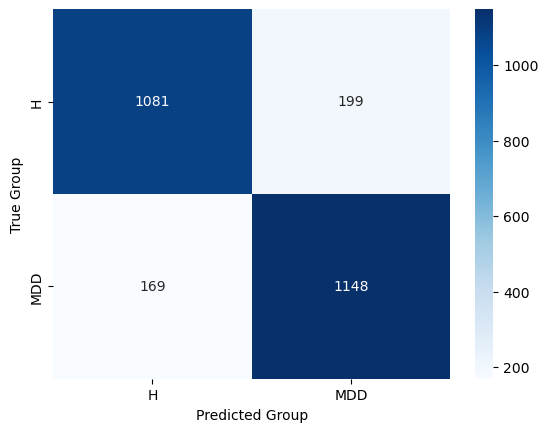

In [11]:
cm = confusion_matrix(y_train[y_index], y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H', 'MDD'],
            yticklabels=['H', 'MDD'])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.show()

## 8. SVM avec sélection de variables par SelectKBest

Cette approche applique une sélection de variables fondée sur un nombre fixe de caractéristiques. La méthode `SelectKBest` conserve ici les **50 variables les plus discriminantes** selon le test ANOVA (`f_classif`).

Cette stratégie permet de comparer une sélection fixe de variables à l’approche précédente fondée sur un pourcentage.

In [12]:
# Pipeline avec sélection des 50 meilleures variables
model = Pipeline([
        ('scaler', StandardScaler()),
        ('feature_selection', SelectKBest(f_classif, k=50)),
        ('prediction', SVC(kernel='linear', C=100, gamma=1))
                 ])


# Conteneurs pour stocker les prédictions et les indices
y_pred = [] 
y_index = []

# Validation croisée à 10 plis
skf = KFold(n_splits=10, shuffle=True, random_state=123)

# Sous-ensembles d'entraînement et de test pour le pli courant 
for tr_ind, te_ind in skf.split(X_train):
    X_tr = X_train[tr_ind]
    y_tr = y_train[tr_ind]
    X_te = X_train[te_ind]

    # Stockage des indices des observations testées
    y_index += list(te_ind) 
    
    # Entraînement du modèle
    model.fit(X_tr, y_tr) 

    # Prédictions sur le sous-ensemble test
    predictions = model.predict(X_te).tolist() 
    y_pred += predictions 

### 8.1 Évaluation de l’exactitude

In [13]:
acc = accuracy_score(y_train[y_index], y_pred)

print('ACC:',acc)

ACC: 0.9125914516750097


### 8.2 Matrice de confusion

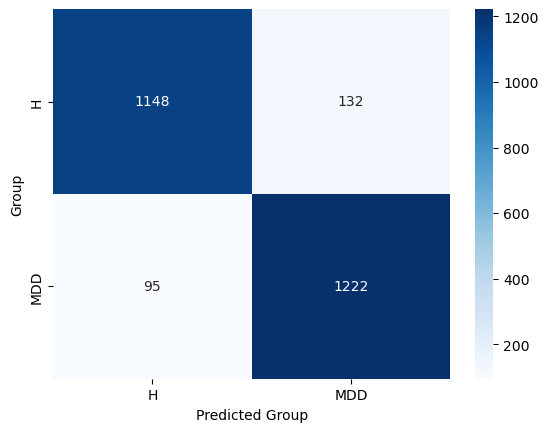

In [14]:
cm = confusion_matrix(y_train[y_index], y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H', 'MDD'],
            yticklabels=['H', 'MDD'])
plt.xlabel('Predicted Group')
plt.ylabel('Group')
plt.show()

## 9. SVM avec réduction de dimension par PCA

Cette dernière variante applique une réduction de dimension à l’aide d’une analyse en composantes principales (**PCA**) avant la classification. La PCA projette les données dans un espace de plus faible dimension tout en conservant une partie importante de la variance initiale.

Ici, les caractéristiques sont réduites à **10 composantes principales** avant l’entraînement du SVM.

In [15]:
# Pipeline avec réduction de dimension par PCA avant la classification
model = Pipeline([
        ('scaler', StandardScaler()),
        ('dim_reduction', PCA(n_components=10, random_state=123)),
        ('prediction', SVC(kernel='linear', C=100, gamma=1))
                 ])

# Conteneurs pour stocker les prédictions et les indices
y_pred = [] 
y_index = [] 

# Validation croisée à 10 plis
skf = KFold(n_splits=10, shuffle=True, random_state=123)

# Sous-ensembles d'entraînement et de test pour le pli courant
for tr_ind, te_ind in skf.split(X_train):
    X_tr = X_train[tr_ind]
    y_tr = y_train[tr_ind]
    X_te = X_train[te_ind]

    # Stockage des indices des observations testées
    y_index += list(te_ind)
    
    # Entraînement du modèle
    model.fit(X_tr, y_tr) 

    # Prédictions sur le sous-ensemble test
    predictions = model.predict(X_te).tolist() 
    y_pred += predictions 


### 9.1 Évalutation de l'exactitude

In [16]:
acc = accuracy_score(y_train[y_index], y_pred)

print('ACC:',acc)

ACC: 0.8255679630342703


### 9.2 Matrice de confusion

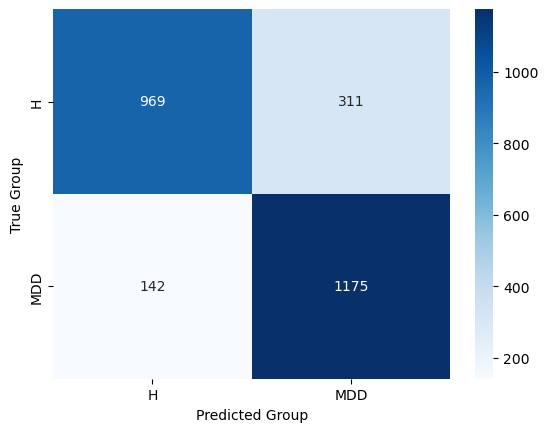

In [17]:
cm = confusion_matrix(y_train[y_index], y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['H', 'MDD'],
            yticklabels=['H', 'MDD'])
plt.xlabel('Predicted Group')
plt.ylabel('True Group')
plt.show()

# Résumé du pipeline

Ce notebook comprend les étapes suivantes :

1. **Importation des librairies**  
   Chargement des bibliothèques nécessaires au traitement des données, à l’entraînement des modèles SVM, à la validation croisée, à la sélection de variables, à la réduction de dimension et à la visualisation des résultats.

2. **Définition des dossiers**  
   Définition des dossiers de travail utilisés pour accéder aux données sources et aux fichiers générés dans le dépôt.

3. **Chargement des caractéristiques prétraitées et des labels**  
   Chargement des matrices produites dans le notebook de prétraitement, soit les données EEG épocées, les caractéristiques extraites et les étiquettes de groupe.

4. **Séparation des données en ensembles d’entraînement et de validation**  
   Division des données en deux sous-ensembles, avec stratification des classes, afin de préserver la proportion des groupes dans chaque ensemble.

5. **Modèle SVM de base avec validation croisée à 10 plis**  
   Entraînement et évaluation d’un modèle SVM linéaire de base sur les caractéristiques EEG.
   
   5.1 **Évaluation de l’exactitude**  
   Calcul de l’accuracy à partir des prédictions obtenues durant la validation croisée.
   
   5.2 **Matrice de confusion**  
   Visualisation des classifications correctes et incorrectes entre les groupes H et MDD.

6. **Ajustement des hyperparamètres avec GridSearchCV**  
   Exploration de différentes combinaisons d’hyperparamètres pour identifier la configuration la plus performante du modèle SVM.

7. **SVM avec sélection de variables par SelectPercentile**  
   Ajout d’une étape de sélection de variables conservant les 20 % de caractéristiques les plus informatives avant la classification.
   
   7.1 **Évaluation de l’exactitude**  
   Calcul de l’accuracy pour cette variante du modèle.
   
   7.2 **Matrice de confusion**  
   Visualisation détaillée des performances du modèle après sélection de variables par percentile.

8. **SVM avec sélection de variables par SelectKBest**  
   Sélection d’un nombre fixe de variables, soit les 50 caractéristiques les plus discriminantes, avant l’entraînement du classificateur.
   
   8.1 **Évaluation de l’exactitude**  
   Calcul de l’accuracy pour cette approche.
   
   8.2 **Matrice de confusion**  
   Visualisation des performances obtenues avec la sélection fixe de variables.

9. **SVM avec réduction de dimension par PCA**  
   Réduction des caractéristiques à 10 composantes principales avant l’entraînement du modèle SVM.
   
   9.1 **Évaluation de l’exactitude**  
   Calcul de l’accuracy après réduction de dimension par PCA.
   
   9.2 **Matrice de confusion**  
   Visualisation des performances du modèle avec réduction de dimension.